# Russell 3000 — Market Cap Heterogeneity in Twitter Sentiment Effects
**Ashley Thompson — Capstone**

Three analyses testing whether the Twitter sentiment → return relationship differs across firm size.

| Analysis | Method | Output |
|---|---|---|
| 1 — Interaction term | Panel OLS with firm FE | `russel_cap_ols.tex` |
| 2 — Temporal by cap group | FMB annual + quarterly | 2 figures, `russel_cap_fmb_annual.tex` |
| 3 — Long-short by cap group | Top/bottom decile within group | `russel_cap_ls_annual.tex` |

**Cap classification (fixed per ticker, based on average `mkt_cap` over the sample):**
- Large: avg market cap > \$10B
- Mid: avg market cap \$2B–\$10B  
- Small: avg market cap < \$2B

**Input:** `russel_panel.csv`  
**Output:** LaTeX tables in `output/`, figures in `output/figures/`, CSVs in `data/processed/`

## 1. Install dependencies

In [1]:
!pip install -q linearmodels pandas_datareader statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.2 MB/s eta 0:00:00


## 2. Mount Drive and clone repo

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE_DIR = '/content/drive/MyDrive/Colab Notebooks/Capstone/'
DATA_PATH = DRIVE_DIR + 'russel_panel.csv'
print(f'Data path: {DATA_PATH}')
print(f'Exists:    {os.path.exists(DATA_PATH)}')

Mounted at /content/drive
Data path: /content/drive/MyDrive/Colab Notebooks/Capstone/russel_panel.csv
Exists:    True


In [3]:
from google.colab import userdata
import os, subprocess

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
REPO_DIR     = '/content/Capstone'

if os.path.exists(REPO_DIR):
    subprocess.run(['git', '-C', REPO_DIR, 'pull'], check=True)
else:
    subprocess.run(
        ['git', 'clone',
         f'https://{GITHUB_TOKEN}@github.com/ATHOMP-03/Capstone.git', REPO_DIR],
        check=True)

DATA_OUT = REPO_DIR + '/data/processed/'
TEX_OUT  = REPO_DIR + '/output/'
FIG_OUT  = REPO_DIR + '/output/figures/'
for d in [DATA_OUT, TEX_OUT, FIG_OUT]:
    os.makedirs(d, exist_ok=True)
print(f'Repo ready: {REPO_DIR}')

Repo ready: /content/Capstone


## 3. Imports and data load

In [4]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from linearmodels.panel import FamaMacBeth, PanelOLS

warnings.filterwarnings('ignore')
np.random.seed(42)

FF_CUTOFF = pd.Timestamp('2026-02-28')

# Cap thresholds in millions of USD
CAP_LARGE = 10_000   # > $10B
CAP_MID   =  2_000   # $2B–$10B  (small = below this)

CAP_ORDER   = ['large', 'mid', 'small']
CAP_COLORS  = {'large': '#1f77b4', 'mid': '#ff7f0e', 'small': '#2ca02c'}
CAP_MARKERS = {'large': 'o',       'mid': 's',       'small': '^'}

long = pd.read_csv(DATA_PATH, parse_dates=['date'])
long = long[long['date'] <= FF_CUTOFF].reset_index(drop=True)
long = long.sort_values(['ticker', 'date']).reset_index(drop=True)

HAS_SPREAD = 'bid_ask_spread' in long.columns

print(f'Loaded {len(long):,} rows  |  {long["ticker"].nunique():,} tickers')
print(f'Date range: {long["date"].min().date()} → {long["date"].max().date()}')
print(f'Bid-ask spread: {"AVAILABLE" if HAS_SPREAD else "MISSING"}')

Loaded 4,448,157 rows  |  2,921 tickers
Date range: 2016-01-04 → 2026-02-27
Bid-ask spread: AVAILABLE


## 4. Variable construction

In [5]:
long['px_open_next'] = long.groupby('ticker')['px_open'].shift(-1)
long['return_oo']    = (long['px_open_next'] - long['px_open']) / long['px_open'] * 100

lH = np.log(long['px_high'].clip(lower=1e-8))
lL = np.log(long['px_low'].clip(lower=1e-8))
lO = np.log(long['px_open'].clip(lower=1e-8))
lC = np.log(long['px_close'].clip(lower=1e-8))
long['vol_rs'] = ((lH - lC) * (lH - lO) + (lL - lC) * (lL - lO)).clip(lower=0) * 100

mv = long.groupby('ticker')['volume'].transform('mean')
long['abnorm_vol']  = ((long['volume'] - mv) / mv) * 100
long['log_mkt_cap'] = np.log(long['mkt_cap'].clip(lower=1e-8))

ctrl_base = ['return_oo', 'abnorm_vol', 'vol_rs', 'log_mkt_cap']
if HAS_SPREAD:
    ctrl_base.append('bid_ask_spread')

for var in ctrl_base:
    for k in range(1, 6):
        long[f'{var}_lag{k}'] = long.groupby('ticker')[var].shift(k)

for k in range(1, 6):
    long[f'twitter_sent_lag{k}'] = long.groupby('ticker')['twitter_sent'].shift(k)
    long[f'news_sent_lag{k}']    = long.groupby('ticker')['news_sent'].shift(k)

print(f'return_oo:    {long["return_oo"].notna().sum():,} obs')
print('Variable construction complete.')

return_oo:    4,445,236 obs
Variable construction complete.


## 5. Fama-French risk adjustment
Full-sample betas estimated once; residuals used in all downstream analyses.

In [6]:
import statsmodels.api as sm
import pandas_datareader.data as web

HAS_ADJ_RETURN = False
try:
    s, e = long['date'].min(), long['date'].max()
    ff3  = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start=s, end=e)[0]
    mom  = web.DataReader('F-F_Momentum_Factor_daily',       'famafrench', start=s, end=e)[0]
    ff3.index = pd.to_datetime(ff3.index, format='%Y%m%d')
    mom.index = pd.to_datetime(mom.index, format='%Y%m%d')
    ff  = ff3.join(mom, how='inner') / 100
    ff.columns = [c.strip() for c in ff.columns]
    print(f'FF factors: {ff.shape[0]} days  |  cols: {list(ff.columns)}')

    merged    = long.merge(
        ff.rename(columns={'Mkt-RF': 'mkt_rf', 'SMB': 'smb', 'HML': 'hml', 'Mom': 'mom'}),
        left_on='date', right_index=True, how='left')
    residuals = np.full(len(merged), np.nan)
    for ticker, grp in merged.groupby('ticker'):
        sub = grp[['return_oo', 'mkt_rf', 'smb', 'hml', 'mom']].dropna()
        if len(sub) < 30:
            continue
        X = sm.add_constant(sub[['mkt_rf', 'smb', 'hml', 'mom']])
        residuals[sub.index] = sm.OLS(sub['return_oo'], X).fit().resid.values
    long['return_oo_adj'] = residuals

    for k in range(1, 6):
        long[f'return_oo_adj_lag{k}'] = long.groupby('ticker')['return_oo_adj'].shift(k)

    HAS_ADJ_RETURN = long['return_oo_adj'].notna().sum() > 1000
    print(f'Risk-adjusted returns: {long["return_oo_adj"].notna().sum():,} obs')

except Exception as ex:
    print(f'FF download failed: {ex}')
    print('Using raw returns throughout.')

DEP_VAR      = 'return_oo_adj' if HAS_ADJ_RETURN else 'return_oo'
DEFAULT_CTRL = ([DEP_VAR, 'abnorm_vol', 'vol_rs', 'log_mkt_cap']
                + (['bid_ask_spread'] if HAS_SPREAD else []))
print(f'Dependent variable: {DEP_VAR}')

FF factors: 2553 days  |  cols: ['Mkt-RF', 'SMB', 'HML', 'RF', 'Mom']
Risk-adjusted returns: 4,445,178 obs
Dependent variable: return_oo_adj


## 6. Cap group assignment
Each ticker gets a **fixed** group based on its average `mkt_cap` over the full sample.
This prevents firms from jumping buckets year-to-year and keeps temporal comparisons clean.

In [7]:
avg_cap = long.groupby('ticker')['mkt_cap'].mean()
cap_map = pd.cut(
    avg_cap,
    bins=[0, CAP_MID, CAP_LARGE, np.inf],
    labels=['small', 'mid', 'large']
)
long['cap_group'] = long['ticker'].map(cap_map)

print('Cap group composition:')
for g in CAP_ORDER:
    n_tickers = (avg_cap.index.isin(cap_map[cap_map == g].index)).sum()
    n_obs     = (long['cap_group'] == g).sum()
    print(f'  {g:6s}  {n_tickers:4d} tickers  {n_obs:>10,} obs')

Cap group composition:
  large    595 tickers   1,006,769 obs
  mid      934 tickers   1,454,374 obs
  small   1392 tickers   1,987,014 obs


## 7. Helper functions

In [8]:
def stars(p):
    if pd.isna(p): return ''
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

def fmt(v, d=4):
    return f'{v:.{d}f}' if (v is not None and not pd.isna(v)) else '---'

def _ctrl_note():
    base = r'5 lags each of return, abnorm\_vol, vol\_rs, log\_mkt\_cap'
    return base + (r', bid\_ask\_spread' if HAS_SPREAD else '')

def fit_fmb(dep, treatment_cols, data, oth_vars=None, n_lags=5, bandwidth=5, min_cs=20):
    if oth_vars is None:
        oth_vars = DEFAULT_CTRL
    controls = [f'{v}_lag{k}' for v in oth_vars for k in range(1, n_lags + 1)]
    formula  = dep + ' ~ ' + ' + '.join(treatment_cols + controls)
    try:
        panel = data.set_index(['ticker', 'date']) if 'ticker' in data.columns else data
        cs    = panel.groupby(level='date').size()
        valid = set(cs[cs >= min_cs].index)
        for col in treatment_cols + controls:
            if col in panel.columns:
                cv = panel.groupby(level='date')[col].std()
                valid -= set(cv[cv.isna() | (cv == 0)].index)
        panel = panel[panel.index.get_level_values('date').isin(valid)]
        if panel.index.get_level_values('date').nunique() < 10:
            return None
        mod = FamaMacBeth.from_formula(formula, data=panel)
        try:
            return mod.fit(cov_type='kernel', bandwidth=bandwidth)
        except Exception:
            try:    return mod.fit(cov_type='robust')
            except: return None
    except Exception:
        return None

def extract_fmb(res, param):
    if res is None or param not in res.params.index:
        return {'coef': np.nan, 'se': np.nan, 'pval': np.nan, 'stars': ''}
    c  = float(res.params[param])
    s  = float(res.std_errors[param])
    pv = float(res.pvalues[param])
    return {'coef': c, 'se': s, 'pval': pv, 'stars': stars(pv)}

def long_short_stats(data):
    df = data[['date', 'ticker', 'twitter_sent', 'return_oo']].dropna().copy()
    df['pct_rank'] = df.groupby('date')['twitter_sent'].rank(pct=True)
    df['side']     = df['pct_rank'].apply(
        lambda r: 'long' if r >= 0.9 else ('short' if r <= 0.1 else None))
    df = df.dropna(subset=['side'])
    daily = (df.groupby(['date', 'side'])['return_oo']
               .mean().unstack('side').dropna(subset=['long', 'short']))
    if daily.empty:
        return {'ls_mean_daily': np.nan, 'ls_ann_return': np.nan,
                'ls_sharpe': np.nan, 'ls_win_rate': np.nan, 'ls_n_days': 0}
    daily['ls'] = daily['long'] - daily['short']
    mu, sigma   = daily['ls'].mean(), daily['ls'].std()
    return {'ls_mean_daily': mu, 'ls_ann_return': mu * 252,
            'ls_sharpe': (mu / sigma) * np.sqrt(252) if sigma > 0 else np.nan,
            'ls_win_rate': (daily['ls'] > 0).mean(), 'ls_n_days': len(daily)}

print('Helper functions defined.')

Helper functions defined.


## 8. Analysis 1 — Panel OLS with interaction term
Five columns: (1) full-sample baseline, (2) full-sample with `twitter_sent × log_mkt_cap` interaction, (3) large cap only, (4) mid cap only, (5) small cap only.  
All models include firm fixed effects and cluster SEs by entity.

In [9]:
CTRL_VARS = ['log_mkt_cap', 'abnorm_vol', 'vol_rs'] + (['bid_ask_spread'] if HAS_SPREAD else [])
ctrl_str  = ' + '.join(CTRL_VARS)

def run_panel_ols(data, formula_rhs, label=''):
    try:
        panel = data.set_index(['ticker', 'date'])
        mod   = PanelOLS.from_formula(
            f'{DEP_VAR} ~ {formula_rhs} + EntityEffects',
            data=panel, drop_absorbed=True
        )
        res = mod.fit(cov_type='clustered', cluster_entity=True)
        ts  = res.params.get('twitter_sent', np.nan)
        print(f'  [{label}]  N={res.nobs:,}  twitter_sent={ts:.4f}')
        return res
    except Exception as ex:
        print(f'  [{label}]  FAILED: {ex}')
        return None

f_base        = f'twitter_sent + {ctrl_str}'
f_interaction = (f'twitter_sent * log_mkt_cap + abnorm_vol + vol_rs'
                 + (' + bid_ask_spread' if HAS_SPREAD else ''))

ols_results = {
    'full_base':        run_panel_ols(long,                              f_base,        'Full — baseline'),
    'full_interaction': run_panel_ols(long,                              f_interaction, 'Full — interaction'),
    'large':            run_panel_ols(long[long['cap_group'] == 'large'], f_base,       'Large cap'),
    'mid':              run_panel_ols(long[long['cap_group'] == 'mid'],   f_base,       'Mid cap'),
    'small':            run_panel_ols(long[long['cap_group'] == 'small'], f_base,       'Small cap'),
}

  [Full — baseline]  N=1,972,274  twitter_sent=0.7081
  [Full — interaction]  N=1,972,274  twitter_sent=1.9411
  [Large cap]  N=763,274  twitter_sent=0.3754
  [Mid cap]  N=640,932  twitter_sent=0.8044
  [Small cap]  N=568,068  twitter_sent=0.9421


In [10]:
def _ols_cell(res, param):
    if res is None or param not in res.params.index:
        return '---', ''
    c  = res.params[param]
    s  = res.std_errors[param]
    pv = res.pvalues[param]
    return f'${fmt(c)}{stars(pv)}$', f'$({fmt(s)})$'

_params = [
    (r'twitter\_sent',                          'twitter_sent'),
    (r'log\_mkt\_cap',                         'log_mkt_cap'),
    (r'twitter\_sent $\times$ log\_mkt\_cap',  'twitter_sent:log_mkt_cap'),
]
_cols  = ['full_base', 'full_interaction', 'large', 'mid', 'small']
_heads = ['(1) Full', '(2) Full+Int.', '(3) Large', '(4) Mid', '(5) Small']

rows = []
for label_tex, param_key in _params:
    c_cells, s_cells = [], []
    for col in _cols:
        c, s = _ols_cell(ols_results[col], param_key)
        c_cells.append(c)
        s_cells.append(s)
    rows.append(' & '.join([label_tex] + c_cells) + ' \\\\')
    rows.append(' & '.join(['']         + s_cells) + ' \\\\')
    rows.append(r'\addlinespace[0.5ex]')

n_row  = 'Observations'
r2_row = '$R^2$ (within)'
for col in _cols:
    r = ols_results[col]
    n_row  += f' & {int(r.nobs):,}'     if r is not None else ' & ---'
    r2_row += f' & {fmt(r.rsquared, 3)}' if r is not None else ' & ---'
n_row  += ' \\\\'
r2_row += ' \\\\'

ncols    = len(_cols) + 1
col_spec = 'l' + 'c' * len(_cols)
head_str = ' & '.join([''] + _heads)

tex_ols = (
    r'\begin{table}[htbp]' + '\n'
    r'\centering' + '\n'
    r'\caption{Panel OLS: Twitter Sentiment $\times$ Market Cap --- Russell 3000}' + '\n'
    r'\label{tab:russel_cap_ols}' + '\n'
    f'\\begin{{tabular}}{{{col_spec}}}\n'
    r'\hline\hline' + '\n'
    f'{head_str} \\\\\n'
    r'\hline' + '\n'
    r'\addlinespace[1ex]' + '\n'
    + '\n'.join(rows) + '\n'
    r'\midrule' + '\n'
    r'\addlinespace[0.5ex]' + '\n'
    + 'Firm FE' + ' & Yes' * len(_cols) + ' \\\\\n'
    r'\addlinespace[0.5ex]' + '\n'
    + n_row + '\n'
    r'\addlinespace[0.5ex]' + '\n'
    + r2_row + '\n'
    r'\hline\hline' + '\n'
    f'\\multicolumn{{{ncols}}}{{p{{0.95\\linewidth}}}}{{\\footnotesize \\textit{{Notes:}} '
    'Panel OLS with firm fixed effects. Clustered SEs (by entity) in parentheses. '
    f'Dependent variable: \\texttt{{{DEP_VAR}}}. '
    'Columns (3)--(5) restrict to cap group defined by average \\texttt{{mkt\\_cap}}: '
    'Large $>\\$10$B, Mid \\$2B--\\$10B, Small $<\\$2$B. '
    r'*** $p<0.01$, ** $p<0.05$, * $p<0.1$.}}' + '\n'
    r'\end{tabular}' + '\n'
    r'\end{table}'
)
with open(TEX_OUT + 'russel_cap_ols.tex', 'w') as f:
    f.write(tex_ols)
print('Saved russel_cap_ols.tex')

Saved russel_cap_ols.tex


## 9. Analysis 2 — Temporal FMB by cap group
For each annual and quarterly window, run FMB separately for large, mid, and small cap firms.  
Expect ~5–10 min for quarterly (160+ windows × 3 groups each).

In [11]:
def annual_windows():
    windows = []
    for y in range(2016, 2027):
        s = pd.Timestamp(y, 1, 1)
        e = pd.Timestamp(y, 2, 28) if y == 2026 else pd.Timestamp(y, 12, 31)
        windows.append((str(y) if y < 2026 else '2026 (Jan-Feb)', s, e))
    return windows

def quarterly_windows():
    windows = []
    for y in range(2016, 2027):
        for q in range(1, 5):
            qm = (q - 1) * 3 + 1
            s  = pd.Timestamp(y, qm, 1)
            e  = pd.Timestamp(y, qm + 2, 1) + pd.offsets.MonthEnd(0)
            if s > pd.Timestamp(2026, 1, 1):
                break
            windows.append((f'{y}-Q{q}', s, e))
        else:
            continue
        break
    return windows

print(f'Annual windows:    {len(annual_windows())}')
print(f'Quarterly windows: {len(quarterly_windows())}')

Annual windows:    11
Quarterly windows: 41


In [12]:
def run_window_by_cap(label, start, end, bandwidth, min_cs):
    sub = long[(long['date'] >= start) & (long['date'] <= end)].copy()
    row = {
        'window_label': label,
        'window_start': start.date(),
        'window_end':   end.date(),
        'n_dates':      sub['date'].nunique(),
        'n_obs':        len(sub),
    }
    if sub['date'].nunique() < 10:
        for grp in CAP_ORDER + ['full']:
            for k in ['coef', 'se', 'pval', 'stars']:
                row[f'{grp}_fmb_{k}'] = np.nan if k != 'stars' else ''
            row[f'{grp}_ls_sharpe'] = np.nan
            row[f'{grp}_ls_n_days'] = 0
        return row

    for grp_name, grp_data in [('full', sub)] + [(g, sub[sub['cap_group'] == g]) for g in CAP_ORDER]:
        if len(grp_data) < 100:
            for k in ['coef', 'se', 'pval', 'stars']:
                row[f'{grp_name}_fmb_{k}'] = np.nan if k != 'stars' else ''
            row[f'{grp_name}_ls_sharpe'] = np.nan
            row[f'{grp_name}_ls_n_days'] = 0
            continue
        res = fit_fmb(DEP_VAR, ['twitter_sent_lag1'], grp_data,
                      bandwidth=bandwidth, min_cs=min_cs)
        est = extract_fmb(res, 'twitter_sent_lag1')
        row[f'{grp_name}_fmb_coef']  = est['coef']
        row[f'{grp_name}_fmb_se']    = est['se']
        row[f'{grp_name}_fmb_pval']  = est['pval']
        row[f'{grp_name}_fmb_stars'] = est['stars']
        ls = long_short_stats(grp_data)
        row[f'{grp_name}_ls_sharpe'] = ls['ls_sharpe']
        row[f'{grp_name}_ls_n_days'] = ls['ls_n_days']
    return row

print('run_window_by_cap() defined.')

run_window_by_cap() defined.


In [13]:
FREQ_CONFIG = [
    ('annual',    annual_windows(),    5, 20),
    ('quarterly', quarterly_windows(), 4, 15),
]

temporal_by_cap = {}

for freq, windows, bw, mcs in FREQ_CONFIG:
    print(f'\n{"="*60}')
    print(f'  {freq.upper()}  ({len(windows)} windows, bandwidth={bw}, min_cs={mcs})')
    print('='*60)
    rows = []
    for label, start, end in windows:
        row = run_window_by_cap(label, start, end, bandwidth=bw, min_cs=mcs)
        rows.append(row)
        parts = [f'  {label:<16}']
        for g in CAP_ORDER:
            c = row.get(f'{g}_fmb_coef', np.nan)
            s = row.get(f'{g}_fmb_stars', '')
            parts.append(f'{g}={c:>8.4f}{s:3s}' if not pd.isna(c) else f'{g}=     n/a   ')
        print(''.join(parts))
    df = pd.DataFrame(rows)
    temporal_by_cap[freq] = df
    df.to_csv(DATA_OUT + f'russel_cap_temporal_{freq}.csv', index=False)
    print(f'  Saved russel_cap_temporal_{freq}.csv')


  ANNUAL  (11 windows, bandwidth=5, min_cs=20)
  2016            large= -0.0237   mid=  0.1218***small=  0.1986** 
  2017            large=  0.0093   mid= -0.0099   small= -0.1242   
  2018            large=  0.1711***mid=  0.4334***small=  0.5563***
  2019            large=  0.1548***mid=  0.5093***small=  0.8149***
  2020            large=  0.1634*  mid=  0.3635***small=  0.6860** 
  2021            large=  0.3188** mid=  0.4752*  small=  1.3119   
  2022            large=     n/a   mid=     n/a   small=     n/a   
  2023            large=  0.0744   mid=  0.8995   small=  0.5897*  
  2024            large=     n/a   mid=     n/a   small=     n/a   
  2025            large=  0.0535   mid=  0.3523** small=  0.6738** 
  2026 (Jan-Feb)  large= -0.2834*  mid=  0.5591*  small=  0.6817   
  Saved russel_cap_temporal_annual.csv

  QUARTERLY  (41 windows, bandwidth=4, min_cs=15)
  2016-Q1         large=  0.0017   mid= -0.0182   small=  0.0010   
  2016-Q2         large= -0.0348   mid=  0.050

## 10. Temporal plots — three lines per figure (large / mid / small)

Saved /content/Capstone/output/figures/russel_cap_temporal_annual.png


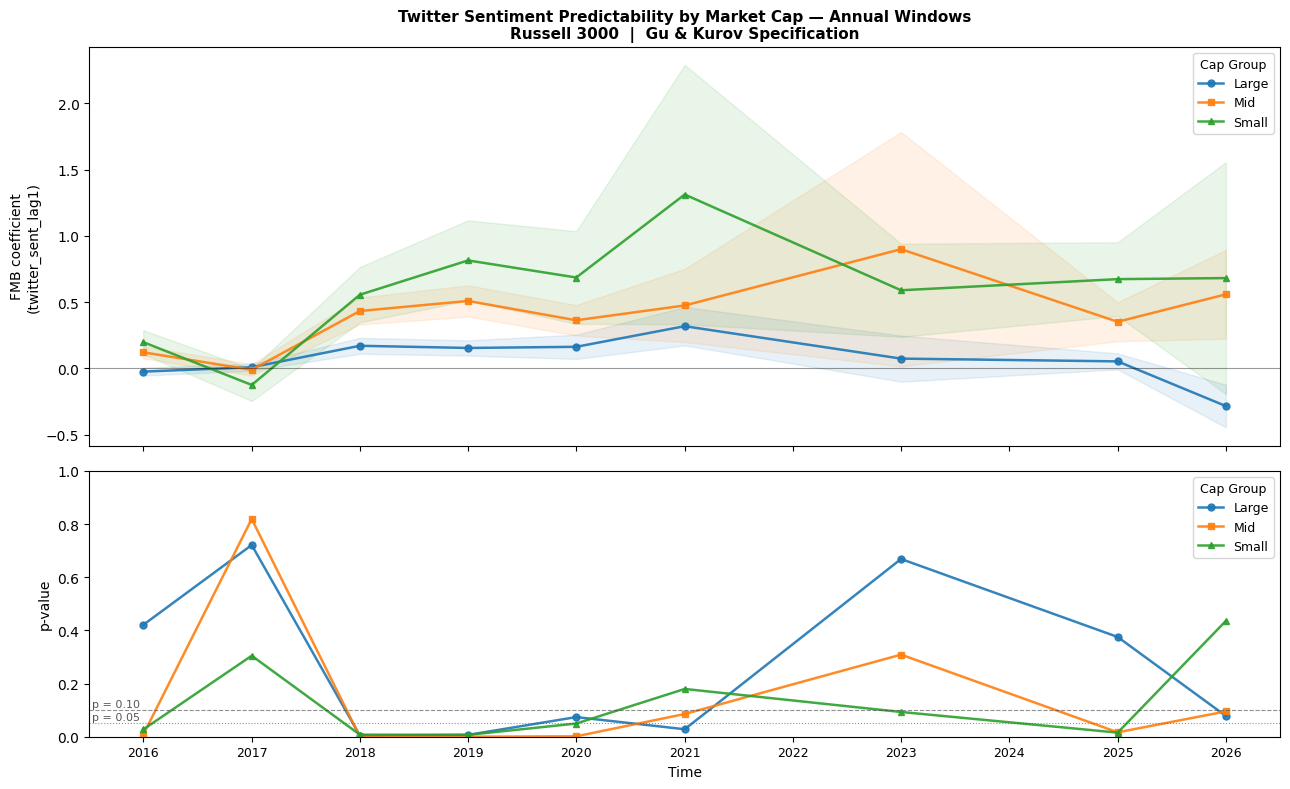

Saved /content/Capstone/output/figures/russel_cap_temporal_quarterly.png


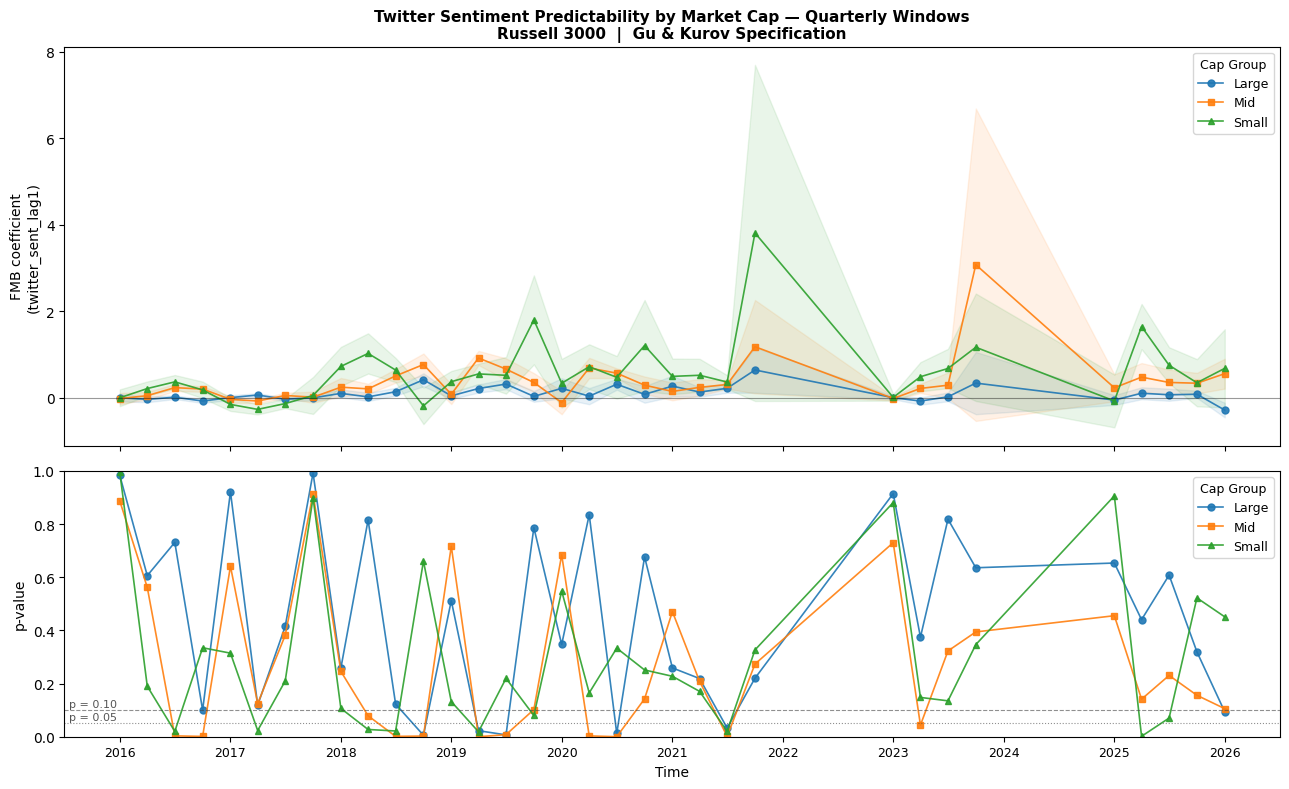

In [14]:
def plot_temporal_by_cap(df, freq_label, out_name):
    d = df.copy()
    d['t'] = pd.to_datetime(d['window_start'])
    d = d.sort_values('t')

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(13, 8), sharex=True,
        gridspec_kw={'height_ratios': [3, 2]}
    )
    fig.subplots_adjust(hspace=0.25)
    lw = 1.8 if 'annual' in out_name else 1.2

    for g in CAP_ORDER:
        sub = d.dropna(subset=[f'{g}_fmb_coef', f'{g}_fmb_se', f'{g}_fmb_pval'])
        if sub.empty:
            continue
        t     = sub['t']
        coef  = sub[f'{g}_fmb_coef']
        se    = sub[f'{g}_fmb_se']
        pval  = sub[f'{g}_fmb_pval']
        color  = CAP_COLORS[g]
        marker = CAP_MARKERS[g]

        ax1.plot(t, coef, color=color, linewidth=lw,
                 marker=marker, markersize=5, alpha=0.9, label=g.capitalize())
        ax1.fill_between(t, coef - se, coef + se, color=color, alpha=0.10)
        ax2.plot(t, pval, color=color, linewidth=lw,
                 marker=marker, markersize=5, alpha=0.9, label=g.capitalize())

    ax1.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)
    ax1.set_ylabel('FMB coefficient\n(twitter_sent_lag1)', fontsize=10)
    ax1.set_title(
        f'Twitter Sentiment Predictability by Market Cap — {freq_label} Windows\n'
        f'Russell 3000  |  Gu & Kurov Specification',
        fontsize=11, fontweight='bold'
    )
    ax1.legend(title='Cap Group', fontsize=9, title_fontsize=9,
               loc='upper right', framealpha=0.8)
    ax1.tick_params(axis='x', labelsize=9)

    ax2.axhline(0.10, color='#444444', linewidth=0.8, linestyle='--', alpha=0.6)
    ax2.axhline(0.05, color='#444444', linewidth=0.8, linestyle=':',  alpha=0.6)
    t_vals = d['t'].dropna()
    if not t_vals.empty:
        t_left = t_vals.iloc[0] - pd.Timedelta(days=10)
        ax2.text(t_left, 0.105, 'p = 0.10', fontsize=8, color='#555555',
                 va='bottom', ha='right')
        ax2.text(t_left, 0.055, 'p = 0.05', fontsize=8, color='#555555',
                 va='bottom', ha='right')
    ax2.set_ylim(0, 1.0)
    ax2.set_ylabel('p-value', fontsize=10)
    ax2.set_xlabel('Time', fontsize=10)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax2.xaxis.set_major_locator(mdates.YearLocator())
    ax2.tick_params(axis='x', labelsize=9)
    ax2.legend(title='Cap Group', fontsize=9, title_fontsize=9,
               loc='upper right', framealpha=0.8)

    fig.tight_layout()
    save_path = FIG_OUT + out_name
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved {save_path}')
    plt.show()

plot_temporal_by_cap(temporal_by_cap['annual'],    'Annual',    'russel_cap_temporal_annual.png')
plot_temporal_by_cap(temporal_by_cap['quarterly'], 'Quarterly', 'russel_cap_temporal_quarterly.png')

## 11. Analysis 3 — Long-short strategy by cap group
Deciles computed **within** each cap group on each date so the strategy is self-contained per segment.

In [15]:
ann_df = temporal_by_cap['annual']

# Print annual summary: FMB coef + Sharpe for each cap group
print(f'{"Year":<20} {"Large coef":>12} {"Mid coef":>12} {"Small coef":>12} '
      f'{"L Sharpe":>10} {"M Sharpe":>10} {"S Sharpe":>10}')
print('-' * 90)
for _, r in ann_df.iterrows():
    parts = [f'{r["window_label"]:<20}']
    for g in CAP_ORDER:
        c = r.get(f'{g}_fmb_coef', np.nan)
        s = r.get(f'{g}_fmb_stars', '')
        parts.append(f'{c:>10.4f}{s:2s}' if not pd.isna(c) else '         n/a')
    for g in CAP_ORDER:
        sh = r.get(f'{g}_ls_sharpe', np.nan)
        parts.append(f'{sh:>10.2f}' if not pd.isna(sh) else '       n/a')
    print(''.join(parts))

Year                   Large coef     Mid coef   Small coef   L Sharpe   M Sharpe   S Sharpe
------------------------------------------------------------------------------------------
2016                   -0.0237      0.1218***    0.1986**      5.30     10.75     -0.07
2017                    0.0093     -0.0099     -0.1242        2.86      4.22      6.20
2018                    0.1711***    0.4334***    0.5563***     12.08     14.91     12.64
2019                    0.1548***    0.5093***    0.8149***     12.37     14.31     12.92
2020                    0.1634*     0.3635***    0.6860**      4.66      7.03      8.81
2021                    0.3188**    0.4752*     1.3119        6.43      3.71      3.90
2022                         n/a         n/a         n/a       n/a       n/a       n/a
2023                    0.0744      0.8995      0.5897*       2.06      4.61      2.72
2024                         n/a         n/a         n/a       n/a       n/a       n/a
2025                    0

## 12. LaTeX exports

In [16]:
def st(p):
    if pd.isna(p): return ''
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

# Long-short Sharpe table (annual, by cap group)
ls_rows = []
for _, r in ann_df.iterrows():
    cells = [r['window_label']]
    for grp in CAP_ORDER + ['full']:
        sh = r.get(f'{grp}_ls_sharpe', np.nan)
        cells.append(fmt(sh, 2) if not pd.isna(sh) else '---')
    ls_rows.append(' & '.join(cells) + ' \\\\')

tex_ls = (
    r'\begin{table}[htbp]' + '\n' + r'\centering' + '\n'
    r'\caption{Long-Short Strategy Sharpe Ratio by Year and Cap Group --- Russell 3000}' + '\n'
    r'\label{tab:russel_cap_ls_annual}' + '\n'
    r'\begin{tabular}{lcccc}' + '\n' + r'\hline\hline' + '\n'
    r'Year & Large & Mid & Small & Full \\' + '\n' + r'\hline' + '\n'
    + '\n'.join(ls_rows) + '\n'
    + r'\hline\hline' + '\n'
    + r'\multicolumn{5}{p{0.9\linewidth}}{\footnotesize \textit{Notes:} '
    + r'Annualized Sharpe ratio of daily long-short portfolio (long top decile / short bottom decile '
    + r'of Twitter sentiment) within each cap group. '
    + r'24-hour holding period (open-to-open). Before transaction costs. '
    + r'Cap groups: Large $>$\$10B, Mid \$2B--\$10B, Small $<$\$2B.} \\' + '\n'
    + r'\end{tabular}' + '\n' + r'\end{table}'
)
with open(TEX_OUT + 'russel_cap_ls_annual.tex', 'w') as f:
    f.write(tex_ls)
print('Saved russel_cap_ls_annual.tex')

# FMB annual table (by cap group)
fmb_rows = []
for _, r in ann_df.iterrows():
    cells = [r['window_label']]
    for grp in CAP_ORDER:
        c  = r.get(f'{grp}_fmb_coef',  np.nan)
        sg = r.get(f'{grp}_fmb_stars', '')
        cells.append(f'${fmt(c)}{sg}$' if not pd.isna(c) else '---')
    fmb_rows.append(' & '.join(cells) + ' \\\\')

tex_fmb = (
    r'\begin{table}[htbp]' + '\n' + r'\centering' + '\n'
    r'\caption{FMB Return Predictability by Year and Cap Group --- Russell 3000}' + '\n'
    r'\label{tab:russel_cap_fmb_annual}' + '\n'
    r'\begin{tabular}{lccc}' + '\n' + r'\hline\hline' + '\n'
    r'Year & Large (>\$10B) & Mid (\$2B--10B) & Small (<\$2B) \\' + '\n' + r'\hline' + '\n'
    + '\n'.join(fmb_rows) + '\n'
    + r'\hline\hline' + '\n'
    + r'\multicolumn{4}{p{0.9\linewidth}}{\footnotesize \textit{Notes:} '
    + r'Fama-MacBeth coefficient on \texttt{twitter\_sent\_lag1} by cap group and year. '
    + f'Dependent variable: \\texttt{{{DEP_VAR}}}. '
    + r'Controls: ' + _ctrl_note() + r' (5 lags each). '
    + r'Newey-West SEs. *** $p<0.01$, ** $p<0.05$, * $p<0.1$.} \\' + '\n'
    + r'\end{tabular}' + '\n' + r'\end{table}'
)
with open(TEX_OUT + 'russel_cap_fmb_annual.tex', 'w') as f:
    f.write(tex_fmb)
print('Saved russel_cap_fmb_annual.tex')

# Figure environments
FREQ_FIGS = [
    ('annual',    'russel_cap_temporal_annual.png',
     r'Annual windows. Bandwidth = 5 lags; minimum cross-section $N = 20$ per group.'),
    ('quarterly', 'russel_cap_temporal_quarterly.png',
     r'Quarterly windows. Bandwidth = 4 lags; minimum cross-section $N = 15$ per group.'),
]
fig_parts = []
for freq, fname, note in FREQ_FIGS:
    fig_parts.append(
        r'\begin{figure}[htbp]' + '\n' + r'\centering' + '\n'
        f'\\includegraphics[width=\\linewidth]{{figures/{fname}}}\n'
        r'\caption{Twitter Sentiment Predictability by Market Cap --- Russell 3000 '
        f'({freq.capitalize()} windows). '
        r'Top panel: Fama-MacBeth coefficient on \texttt{twitter\_sent\_lag1} '
        r'with $\pm$1 SE band for large (blue), mid (orange), and small (green) cap firms. '
        r'Bottom panel: $p$-values; dashed lines at $p = 0.10$ and $p = 0.05$. '
        + note + r'}' + '\n'
        f'\\label{{fig:russel_cap_temporal_{freq}}}\n'
        r'\end{figure}'
    )
with open(TEX_OUT + 'russel_cap_temporal_fig.tex', 'w') as f:
    f.write('\n\n'.join(fig_parts))
print('Saved russel_cap_temporal_fig.tex')
print('\nAll LaTeX outputs written.')

Saved russel_cap_ls_annual.tex
Saved russel_cap_fmb_annual.tex
Saved russel_cap_temporal_fig.tex

All LaTeX outputs written.


## 13. Save CSVs and push to GitHub

In [17]:
temporal_by_cap['annual'].to_csv(    DATA_OUT + 'russel_cap_temporal_annual.csv',    index=False)
temporal_by_cap['quarterly'].to_csv( DATA_OUT + 'russel_cap_temporal_quarterly.csv', index=False)
print('CSVs saved:')
print(f'  russel_cap_temporal_annual.csv    ({len(temporal_by_cap["annual"])} rows)')
print(f'  russel_cap_temporal_quarterly.csv ({len(temporal_by_cap["quarterly"])} rows)')

import os, subprocess
os.chdir(REPO_DIR)
subprocess.run(['git', 'config', 'user.email', 'althompson9@dons.usfca.edu'], check=True)
subprocess.run(['git', 'config', 'user.name',  'Ashley Thompson'],            check=True)
subprocess.run(['git', 'add',
    'data/processed/russel_cap_temporal_annual.csv',
    'data/processed/russel_cap_temporal_quarterly.csv',
    'output/figures/russel_cap_temporal_annual.png',
    'output/figures/russel_cap_temporal_quarterly.png',
    'output/russel_cap_ols.tex',
    'output/russel_cap_fmb_annual.tex',
    'output/russel_cap_ls_annual.tex',
    'output/russel_cap_temporal_fig.tex',
    'notebooks/russel_cap_analysis_colab.ipynb'], check=True)
subprocess.run(['git', 'commit', '-m',
    'Russell 3000 cap-group analysis: OLS interaction, temporal FMB by cap, L-S by cap'],
    check=True)
subprocess.run(['git', 'push',
    f'https://{GITHUB_TOKEN}@github.com/ATHOMP-03/Capstone.git', 'main'], check=True)
print('Pushed to GitHub.')

CSVs saved:
  russel_cap_temporal_annual.csv    (11 rows)
  russel_cap_temporal_quarterly.csv (41 rows)
Pushed to GitHub.
